<a href="https://colab.research.google.com/github/aaronjoel/DeepLearningTutorials/blob/master/Physics_Inspired_Deep_Learning_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# Generate data
N = 10000
X = np.random.random(N).astype(np.float32).reshape(-1, 1)

# Generation of Y-Data
sign = (-np.ones((N, ))).astype(np.float32) ** np.random.randint(2, size=N)

Y = (np.sqrt(X.flatten()) * sign).reshape(-1, 1).astype(np.float32)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X)
Y_tensor = torch.tensor(Y)

In [3]:
X.shape

(10000, 1)

In [4]:
X[:5]

array([[0.00615004],
       [0.33341622],
       [0.41067043],
       [0.5434505 ],
       [0.68273765]], dtype=float32)

In [5]:
Y[:5]

array([[-0.07842217],
       [-0.577422  ],
       [ 0.6408357 ],
       [-0.73719096],
       [ 0.8262794 ]], dtype=float32)

In [6]:
Y[:5] ** 2

array([[0.00615004],
       [0.3334162 ],
       [0.4106704 ],
       [0.54345053],
       [0.68273765]], dtype=float32)

In [7]:
# Define the neural network
class SimpleNN(nn.Module):
    def __init__(self, hidden_dim=10):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(1, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        #x = self.fc3( self.relu( self.fc2( self.relu( self.fc1( x ) ) ) ) )
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [8]:
nn_sup = SimpleNN(hidden_dim=128)
criterion = nn.MSELoss()
optimizer = optim.Adam(nn_sup.parameters(), lr=0.001)


# Training loop
epochs = 50
batch_size = 5

for epoch in range(epochs):
    permutation = torch.randperm(N)
    epoch_loss = 0.0

    for i in range(0, N, batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_tensor[indices], Y_tensor[indices]

        optimizer.zero_grad()
        outputs = nn_sup(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch % 10 == 9):
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/N:.6f}")

Epoch 10/50, Loss: 0.099699
Epoch 20/50, Loss: 0.099688
Epoch 30/50, Loss: 0.099704
Epoch 40/50, Loss: 0.099702
Epoch 50/50, Loss: 0.099691


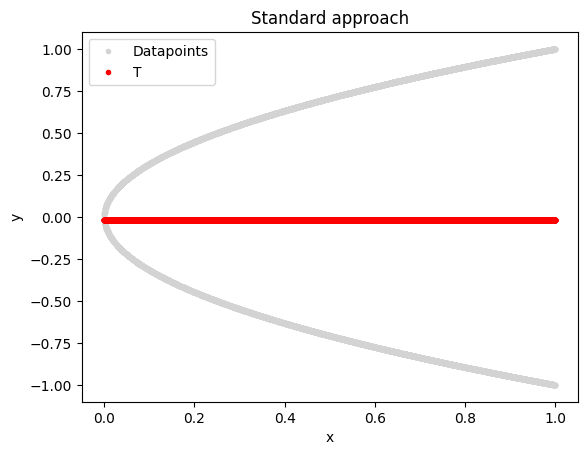

In [9]:
import matplotlib.pyplot as plt

plt.plot(X, Y, '.', label='Datapoints', color='lightgray')
plt.plot(X, nn_sup(torch.tensor(X)).detach(), '.', label='T', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard approach')

plt.legend()
plt.show()

In [10]:
# X-Data
# X = X, we can directly re-use the X from above, nothing has changed...

# P maps Y back to X, simply by computing a square, as y is a TF tensor inplace
def P(y):
    return torch.square(y)

# Define custom loss function using the "physics" operator P
def loss_function(y_true, y_pred):
    return criterion(y_true, P(y_pred))

In [11]:
nn_dp = SimpleNN(hidden_dim=128)
optimizer = optim.Adam(nn_dp.parameters(), lr=0.001)

# Training loop
batch_size = 5

for epoch in range(epochs):
    permutation = torch.randperm(N)
    epoch_loss = 0.0

    for i in range(0, N, batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = X_tensor[indices]

        optimizer.zero_grad()
        outputs = nn_dp(batch_x)
        loss = loss_function(batch_x, outputs)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch % 10 == 9):
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/N:.6f}")

Epoch 10/50, Loss: 0.000004
Epoch 20/50, Loss: 0.000003
Epoch 30/50, Loss: 0.000002
Epoch 40/50, Loss: 0.000003
Epoch 50/50, Loss: 0.000002


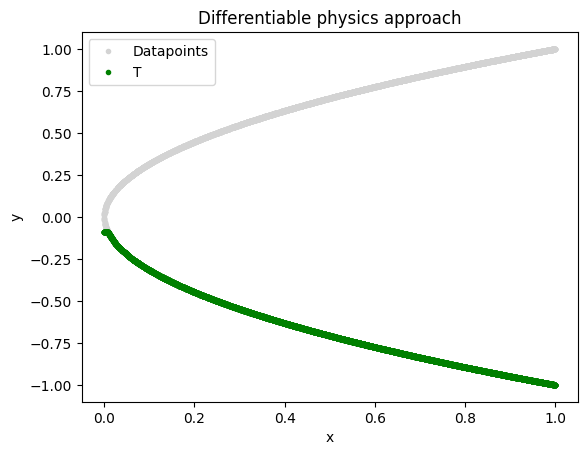

In [12]:
# Results
plt.plot(X, Y, '.', label='Datapoints', color='lightgray')
plt.plot(X, nn_dp(torch.tensor(X)).detach(), '.', label='T', color='green')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Differentiable physics approach')
plt.legend()
plt.show()

In [13]:
np.random.multivariate_normal([0, 0.0], np.eye(2))

array([ 0.08837602, -1.0844066 ])

In [14]:
t = np.random.multivariate_normal([0, 0.0], np.eye(2))
t

array([0.22881634, 2.04998245])

In [15]:
t[0] = 3.4
t

array([3.4       , 2.04998245])

In [16]:
from torch.utils.data import Dataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FlowMatchingDataset(Dataset):
    def __init__(self, data_x, data_y, n_samples=1000, sigma_min=1e-4):
        super().__init__()
        self.n_samples = n_samples
        self.sigma_min = sigma_min
        self.data_x = data_x
        self.data_y = data_y

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x0 = np.random.multivariate_normal([0.0, 0.0], np.eye(2), 1)[0]
        t = np.random.rand()  # scalar in [0,1]
        dx = self.data_x[idx] #:idx+1]
        dy_org = self.data_y[idx]# :idx+1]
        x0[0] = dx[0] # keep x value
        x1 = np.concatenate([dx,dy_org],axis=0)
        #print([self.data_x.shape,dx.shape,x1.shape])

        x_t = (1 - ( 1 - self.sigma_min) * t) * x0 + t * x1
        u_t = (x1 - x0)
        x_t = torch.tensor(x_t, dtype=torch.float32)
        t   = torch.tensor([t], dtype=torch.float32)
        u_t = torch.tensor(u_t, dtype=torch.float32)
        return x_t, t, u_t

In [17]:
class VelocityNet(nn.Module):
    def __init__(self, hidden_dim, in_dim=2, time_dim=1, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim + time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

In [18]:
batch_size = 128

dataset = FlowMatchingDataset(X, Y, n_samples=N)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

nn_fm = VelocityNet(hidden_dim=128).to(device)
optimizer = optim.Adam(nn_fm.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(epochs):
    running_loss = 0.0
    for x_t, t, u_t in dataloader:
        x_t = x_t.to(device)
        t   = t.to(device)
        u_t = u_t.to(device)
        optimizer.zero_grad()
        pred_v = nn_fm(x_t, t)
        loss = criterion(pred_v, u_t)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_t.size(0)
    running_loss /= len(dataset)
    if (epoch % 10 == 9):
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss:.4f}")

Epoch 10/50, Loss: 0.3834
Epoch 20/50, Loss: 0.3721
Epoch 30/50, Loss: 0.3565
Epoch 40/50, Loss: 0.3527
Epoch 50/50, Loss: 0.3472


In [19]:
def integrate_flow(nn, x0, t_span=(0.0, 1.0), n_steps=100):
    trajectory = []
    t = torch.linspace(t_span[0], t_span[1], n_steps).to(x0.device)
    dt = 1./n_steps
    x_in = x0
    for i in range(n_steps):
        x0 = x0 + dt * nn(x0, torch.tensor([i/n_steps]).expand(x0.shape[0], 1) )
        x0[:,0] = x_in[:,0] # condition on original x position
        trajectory.append(x0)
    return trajectory, t

# Generate samples along x, then randomize along y
n_gen = 500
x_in = torch.linspace(0.,1., n_gen).to(device)
y_in = torch.randn(n_gen).to(device) * 0.95
x0_gen = torch.stack([x_in,y_in],axis=-1)
trajectory, time_points = integrate_flow(nn_fm, x0_gen)

In [21]:
import seaborn as sns
sns.set_theme(style='ticks', palette='pastel')

def get_angle_colors(positions):
    angles = np.arctan2(positions[:, 1], positions[:, 0])
    angles_deg = (np.degrees(angles) + 360) % 360
    colors = np.zeros((len(positions), 3))
    for i, angle in enumerate(angles_deg):
        segment = int(angle / 120)
        local_angle = angle - segment * 120
        if segment == 0:
            colors[i] = [1 - local_angle/120, local_angle/120, 0]
        elif segment == 1:
            colors[i] = [0, 1 - local_angle/120, local_angle/120]
        else:
            colors[i] = [local_angle/120, 0, 1 - local_angle/120]
    return colors


desired_times = [0.2, 0.6, 0.8]
time_np = time_points.detach().cpu().numpy()
n_steps = len(time_np)
indices = [np.argmin(np.abs(time_np - t_val)) for t_val in desired_times]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axes= axes.ravel()  # flatten the 2D array for easier indexing

xx, yy = np.mgrid[0:1:100j, -1:1:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])


for i, idx in enumerate(indices):
    ax = axes[i]
    x_t = trajectory[idx].detach().cpu().numpy()
    if i == 0:
        c = get_angle_colors(x_t)
    ax.scatter(x_t[:, 0], x_t[:, 1], alpha=0.5, s=10, color=c)
    ax.set_title(f"t = {time_np[idx]:.2f}")
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

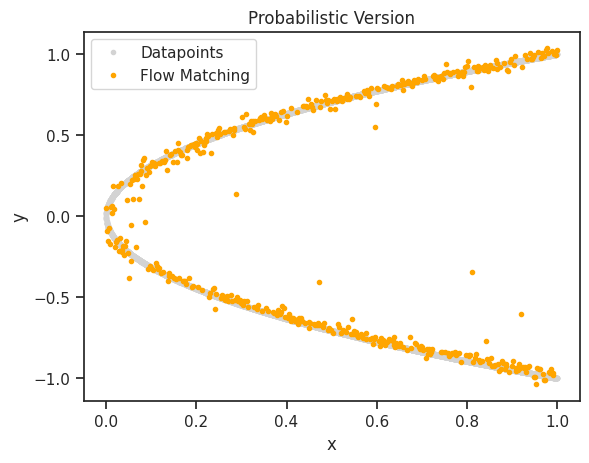

In [22]:
# Results
plt.plot(X,Y,'.',label='Datapoints', color="lightgray")
plt.plot(trajectory[-1][:,0].detach(),trajectory[-1][:,1].detach(),'.',label='Flow Matching', color="orange")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Probabilistic Version')
plt.legend()
plt.show()